# UT8 – Reducción de Dimensionalidad y PCA
## Dataset: Statistical Review of World Energy 2025 (Energy Institute)

### Descripción del dataset

El **Statistical Review of World Energy** (Energy Institute, 2025) es uno de los conjuntos de datos energéticos más completos y fiables del mundo. Recoge métricas anuales de producción, consumo, emisiones y recursos minerales de 141 países y regiones entre 1965 y 2024.

El fichero está disponible en formato **narrow/long** (un registro por país-año-métrica), con las columnas:

| Columna | Descripción |
|---|---|
| `Country` | País o región |
| `Year` | Año (1965–2024) |
| `ISO3166_alpha3` | Código ISO3 del país (NaN para agregados regionales) |
| `Region` | Región geográfica (7 clases) |
| `OECD` | Miembro de la OCDE (0/1) ← **variable objetivo** |
| `EU`, `OPEC`, `CIS` | Otras membresías (0/1) |
| `Var` | Nombre de la métrica energética (90 métricas disponibles) |
| `Value` | Valor numérico de la métrica |

### Justificación del preprocesado

El formato original es **long**: una fila por (país, año, métrica). Para aplicar técnicas de ML necesitamos el formato **wide**: una fila por país, con cada métrica como columna. La transformación se realiza con un `pivot_table`.

**Decisiones de diseño:**
1. **Ventana temporal 2015–2023**: datos más recientes y completos; el promedio por país reduce el ruido interanual.
2. **Solo países individuales** (`ISO3166_alpha3` no nulo): excluimos agregados como "Total North America" que no representan entidades reales.
3. **Selección de métricas con <30% nulos**: de las 90 métricas disponibles, 30 tienen datos suficientes para la mayoría de países; las restantes (minerales críticos, productos refinados detallados) son muy escasas.
4. **Variable objetivo: `OECD`** (binario 0/1): indica si el país es miembro de la OCDE. Es una clasificación bien definida, interpretable y con buena separabilidad en el espacio energético (los países OCDE tienen patrones de consumo y emisiones distintos).
5. **Imputación por mediana**: el ~26% de nulos restante se imputa con la mediana de cada métrica, preservando la distribución y siendo robusto a outliers.

**Resultado final: ~140 países × 30 características energéticas** — dimensionalidad suficiente para aplicar PCA de forma significativa.

---
## 1. Preprocesado de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── 1.1 Carga del dataset ──────────────────────────────────────────────────────
df_raw = pd.read_csv('Statistical Review of World Energy Narrow format.csv')
print(f"Dataset original: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head()

Dataset original: 293,234 filas × 12 columnas


,Country,Year,ISO3166_alpha3,ISO3166_numeric,Region,SubRegion,OPEC,EU,OECD,CIS,Var,Value
0,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,biogeo_ej,0.000000
1,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,co2_combust_mtco2,5.568753
2,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,co2_combust_pc,0.007229
3,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,co2_combust_per_ej,4.242345
4,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,coalcons_ej,0.002931


In [2]:
# ── 1.2 Filtrado: países individuales y ventana 2015-2023 ──────────────────────
# ISO3166_alpha3 es NaN para los agregados regionales (ej. 'Total North America')
df = df_raw[
    df_raw['ISO3166_alpha3'].notna() &
    df_raw['Year'].between(2015, 2023)
].copy()

print(f"Tras filtrado: {len(df):,} filas")
print(f"Países únicos:   {df['Country'].nunique()}")
print(f"Métricas únicas: {df['Var'].nunique()}")
print(f"\nDistribución OECD (nº países únicos):")
print(df.drop_duplicates('Country')['OECD'].value_counts().rename({0:'No OECD', 1:'OECD'}))

Tras filtrado: 51,271 filas
Países únicos:   140
Métricas únicas: 86

Distribución OECD (nº países únicos):
OECD
No OECD    77
OECD       37
Name: count, dtype: int64


In [3]:
# ── 1.3 Pivot a formato wide (país × métrica) ──────────────────────────────────
# Cada fila = un país; cada columna = promedio de la métrica en 2015-2023
df_wide = df.groupby(['Country', 'Var'])['Value'].mean().unstack('Var')

# Recuperar la variable objetivo (OECD) y la región por país
meta = df.drop_duplicates('Country').set_index('Country')[['OECD', 'Region']]
df_wide = df_wide.join(meta)

print(f"Shape tras pivot: {df_wide.shape}")
print(f"\nNulos por métrica — top 10 (%):")
print(df_wide.drop(columns=['OECD','Region']).isna().mean()
      .sort_values(ascending=False).head(10).mul(100).round(1))

Shape tras pivot: (140, 88)

Nulos por métrica — top 10 (%):
lithium_kt                92.9
rareearths_kt             92.9
graphite_kt               90.0
biodiesel_cons_kboed      89.3
cobalt_kt                 89.3
biodiesel_cons_pj         89.3
kerosene_cons_kbd         88.6
diesel_gasoil_cons_kbd    88.6
biodiesel_prod_kboed      88.6
fuel_oil_cons_kbd         88.6
dtype: float64


In [4]:
# ── 1.4 Selección de características con <30% nulos ───────────────────────────
feature_cols = [c for c in df_wide.columns if c not in ['OECD','Region']]
null_pct = df_wide[feature_cols].isna().mean()
selected_features = null_pct[null_pct < 0.30].index.tolist()

print(f"Métricas disponibles:                       {len(feature_cols)}")
print(f"Métricas seleccionadas (<30% nulos):        {len(selected_features)}")
print(f"\nCaracterísticas seleccionadas:")
for f in sorted(selected_features):
    print(f"  {f:35s}  {null_pct[f]*100:.1f}% nulos")

Métricas disponibles:                       86
Métricas seleccionadas (<30% nulos):        30

Características seleccionadas:
  biogeo_ej                            25.0% nulos
  biogeo_twh                           25.7% nulos
  biogeo_twh_net                       25.7% nulos
  co2_combust_mtco2                    25.7% nulos
  co2_combust_pc                       25.7% nulos
  co2_combust_per_ej                   25.0% nulos
  coalcons_ej                          26.4% nulos
  elect_twh                            25.7% nulos
  gascons_bcfd                         28.6% nulos
  gascons_bcm                          28.6% nulos
  gascons_ej                           28.6% nulos
  hydro_ej                             25.0% nulos
  liqcons_kbd                          25.7% nulos
  nuclear_ej                           25.0% nulos
  oilcons_ej                           25.7% nulos
  oilcons_kbd                          25.7% nulos
  oilcons_mt                           25.7% nulos
  pop  

In [5]:
# ── 1.5 Dataset final: X (features) e y (target) ─────────────────────────────
df_model = df_wide[selected_features + ['OECD']].dropna(subset=['OECD'])

X_raw = df_model[selected_features].copy()
y     = df_model['OECD'].astype(int)

print(f"Dimensiones del dataset: {X_raw.shape}")
print(f"\nDistribución de la clase objetivo:")
print(y.value_counts().rename({0:'No OECD (0)', 1:'OECD (1)'}))
print(f"\nNulos en X antes de imputación: {X_raw.isna().sum().sum()} celdas ({X_raw.isna().mean().mean()*100:.1f}%)")

Dimensiones del dataset: (114, 30)

Distribución de la clase objetivo:
OECD
No OECD (0)    77
OECD (1)       37
Name: count, dtype: int64

Nulos en X antes de imputación: 873 celdas (25.5%)


In [6]:
# ── 1.6 Imputación, Train/Test split y normalización ─────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Dividir ANTES de imputar para evitar data leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=0, stratify=y
)

# Imputar con mediana (robusta a outliers) — fit solo en train
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp  = imputer.transform(X_test_raw)

# Normalizar con StandardScaler (imprescindible para PCA y algoritmos de distancia)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_imp)
X_test  = scaler.transform(X_test_imp)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"y_train — OECD: {y_train.sum()}  No OECD: {(y_train==0).sum()}")
print(f"y_test  — OECD: {y_test.sum()}  No OECD: {(y_test==0).sum()}")

Train: (91, 30)  |  Test: (23, 30)
y_train — OECD: 30  No OECD: 61
y_test  — OECD: 7  No OECD: 16


---
## 2. Modelo de clasificación base

Antes de aplicar ninguna técnica de reducción de dimensionalidad, entrenamos un modelo de clasificación con todas las características. Este resultado servirá como **línea base** para comparar la pérdida o ganancia de rendimiento al reducir dimensionalidad.

**Modelo elegido:** Regresión Logística (`class_weight='balanced'` para compensar el ligero desbalance de clases 37 OECD vs 77 no-OECD).

=== MODELO BASE (30 características) ===
              precision    recall  f1-score   support

     No OECD       0.93      0.81      0.87        16
        OECD       0.67      0.86      0.75         7

    accuracy                           0.83        23
   macro avg       0.80      0.83      0.81        23
weighted avg       0.85      0.83      0.83        23



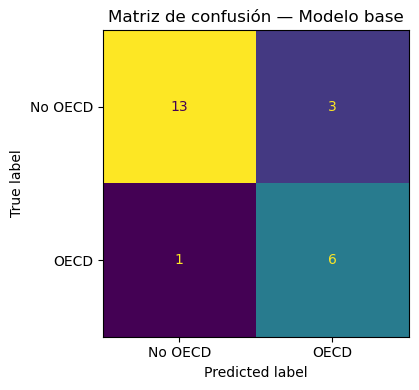

Accuracy modelo base: 0.826


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Modelo base con todas las características
clf_base = LogisticRegression(max_iter=1000, random_state=0, class_weight='balanced')
clf_base.fit(X_train, y_train)

y_pred_base = clf_base.predict(X_test)

print("=== MODELO BASE (30 características) ===")
print(classification_report(y_test, y_pred_base, target_names=['No OECD','OECD']))

fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_base),
                       display_labels=['No OECD','OECD']).plot(ax=ax, colorbar=False)
ax.set_title('Matriz de confusión — Modelo base')
plt.tight_layout()
plt.show()

acc_base = clf_base.score(X_test, y_test)
print(f"Accuracy modelo base: {acc_base:.3f}")

---
## 3. Análisis de correlación

El análisis de correlación es el primer paso en la selección de características. Si dos características están muy correladas, una de ellas aporta información redundante y puede eliminarse sin perder poder predictivo.

En un dataset energético es esperable encontrar **correlaciones muy altas** entre métricas que miden el mismo fenómeno en distintas unidades (p.ej. `solar_ej` y `solar_twh`) o variables fuertemente ligadas físicamente (p.ej. consumo de carbón y emisiones de CO₂).

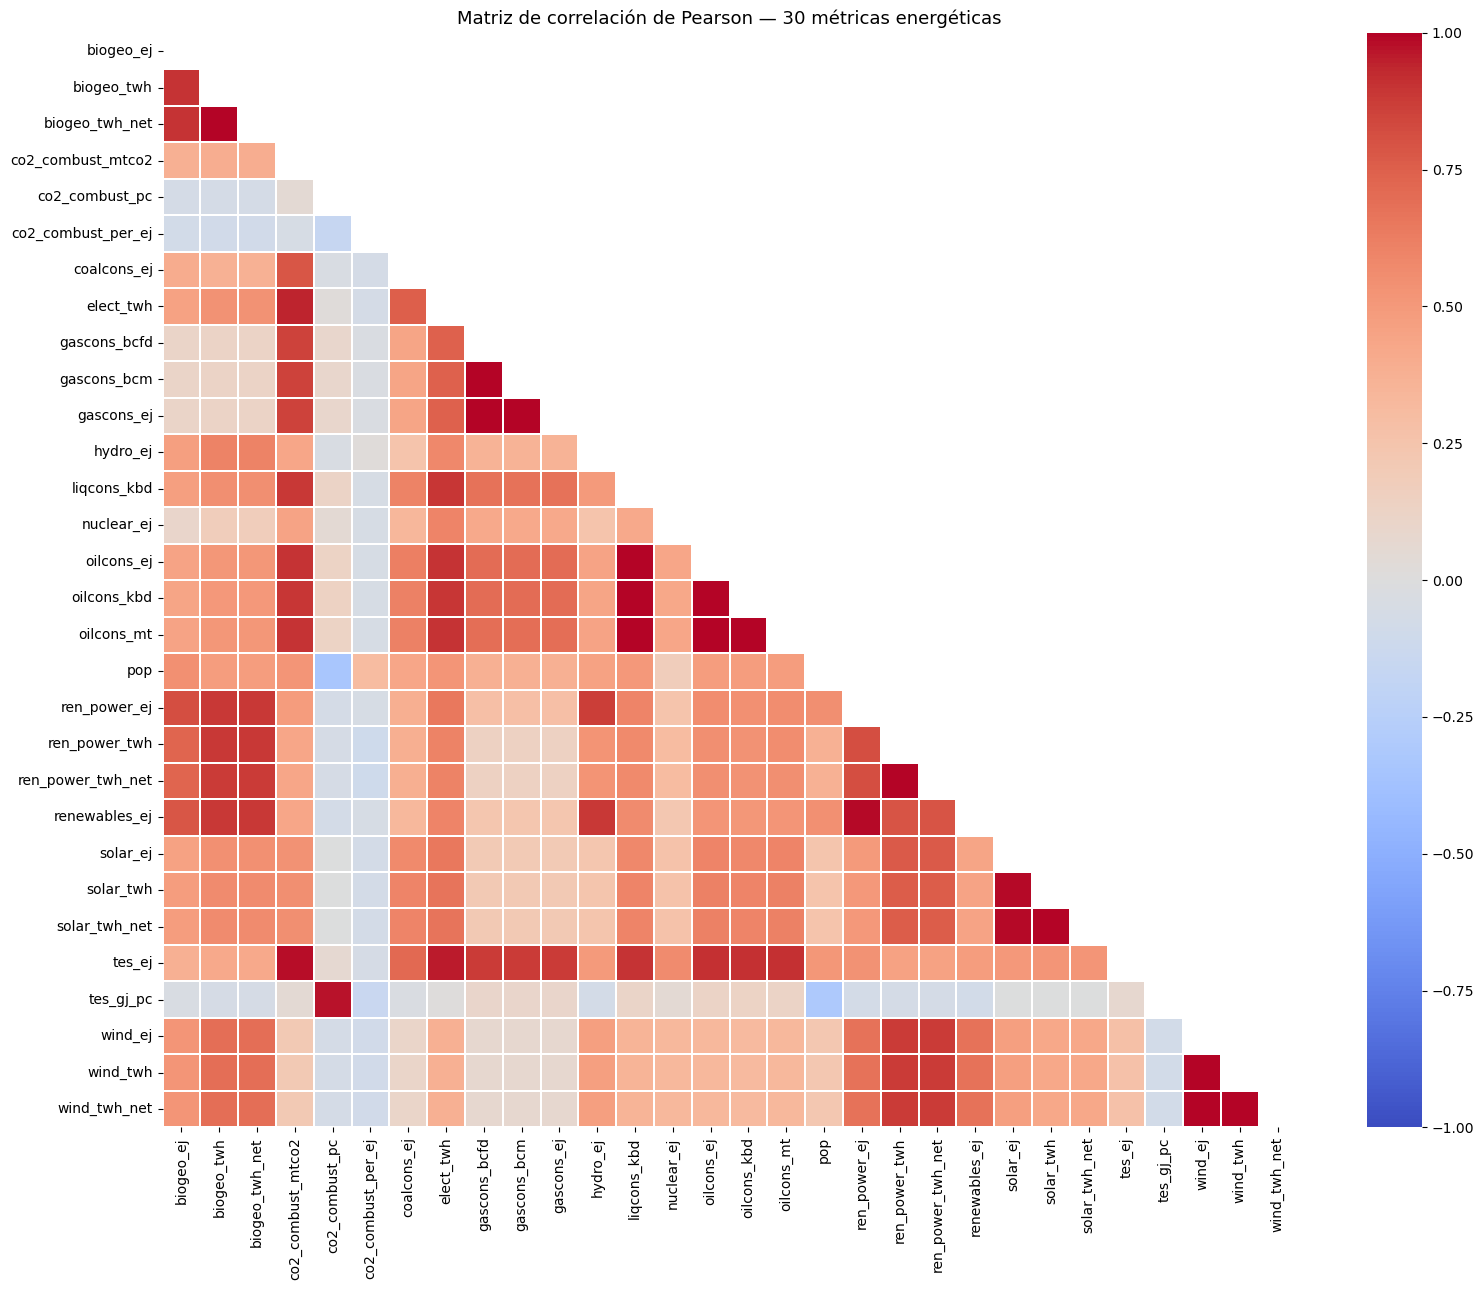

In [8]:
# Calcular correlaciones sobre los datos de entrenamiento imputados (sin escalar)
df_train_imp = pd.DataFrame(X_train_imp, columns=selected_features)
corr_matrix = df_train_imp.corr()

# Heatmap completo
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.3, ax=ax)
ax.set_title('Matriz de correlación de Pearson — 30 métricas energéticas', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# Pares con correlación muy alta (|r| > 0.95)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.95:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r,3)))

df_hc = pd.DataFrame(high_corr, columns=['Feature A', 'Feature B', 'Pearson r'])
df_hc = df_hc.sort_values('Pearson r', ascending=False)
print(f"Pares con |r| > 0.95: {len(df_hc)}")
df_hc

Pares con |r| > 0.95: 21


,Feature A,Feature B,Pearson r
0,biogeo_twh,biogeo_twh_net,1.000
11,oilcons_ej,oilcons_mt,1.000
19,wind_ej,wind_twh_net,1.000
18,wind_ej,wind_twh,1.000
17,solar_twh,solar_twh_net,1.000
14,ren_power_twh,ren_power_twh_net,1.000
20,wind_twh,wind_twh_net,1.000
6,gascons_bcm,gascons_ej,1.000
5,gascons_bcfd,gascons_ej,1.000
4,gascons_bcfd,gascons_bcm,1.000


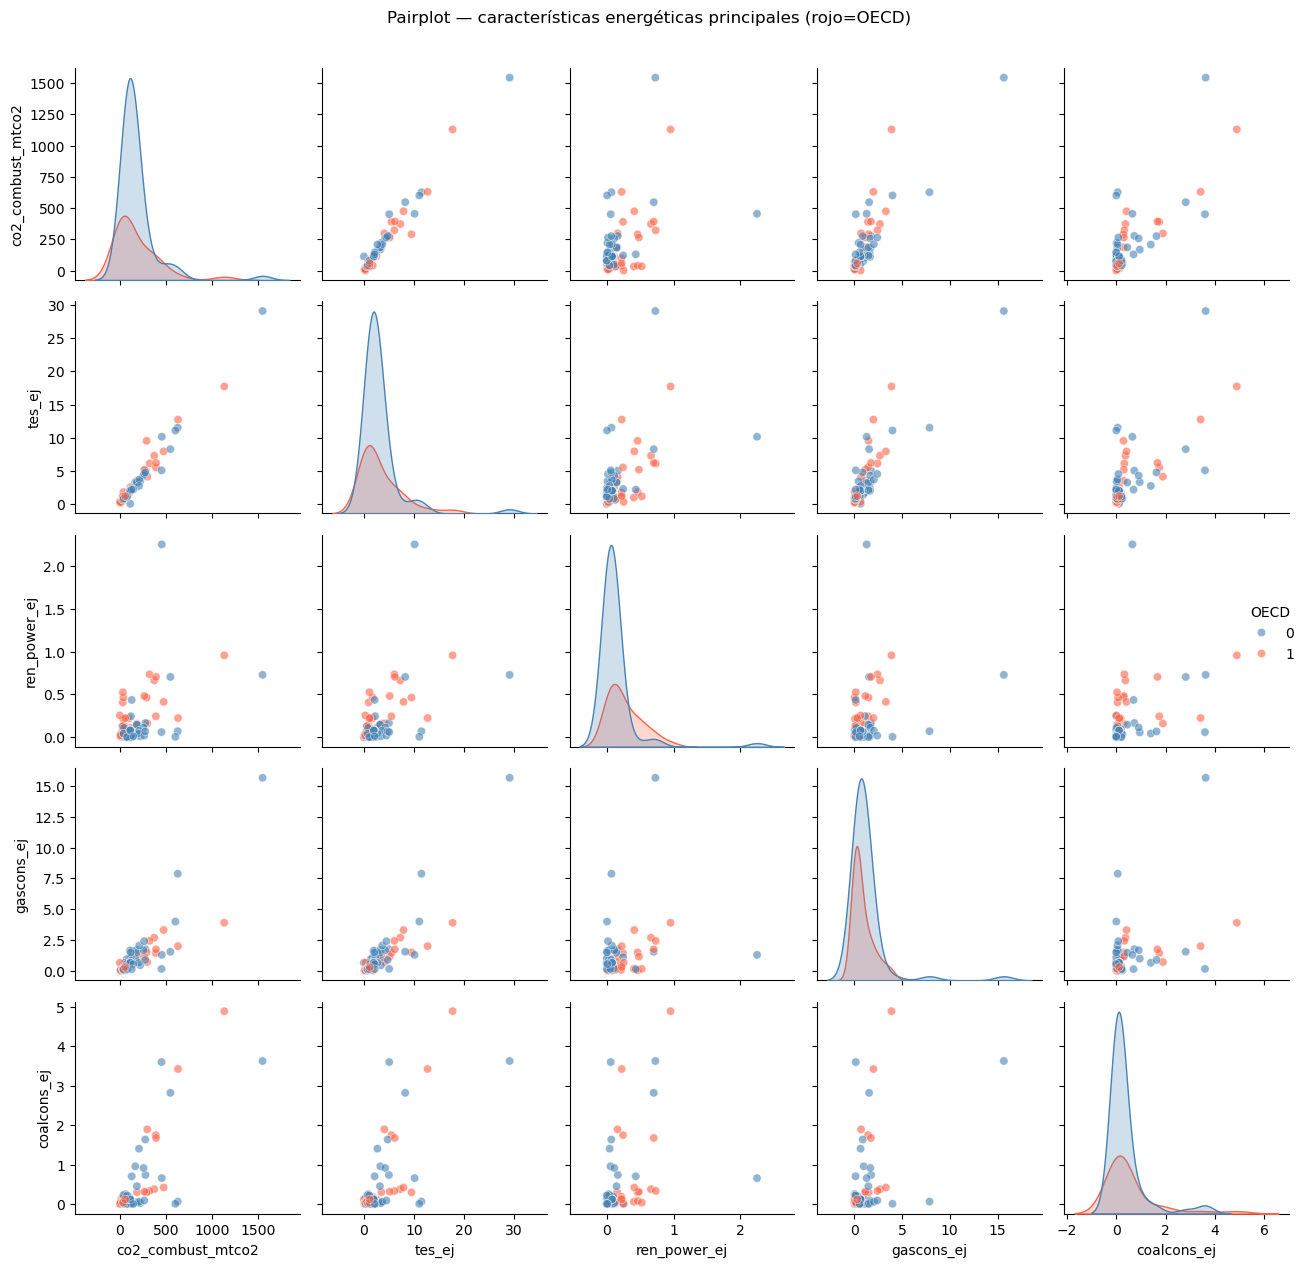

In [10]:
# Pairplot de un subconjunto representativo
subset_cols = ['co2_combust_mtco2', 'tes_ej', 'ren_power_ej', 'gascons_ej', 'coalcons_ej']
df_pair = df_train_imp[subset_cols].copy()
df_pair['OECD'] = y_train.values

sns.pairplot(df_pair, hue='OECD', palette={0:'steelblue', 1:'tomato'},
             plot_kws={'alpha':0.6}, diag_kind='kde')
plt.suptitle('Pairplot — características energéticas principales (rojo=OECD)', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Feature Importances (Importancia de características)

Los algoritmos basados en árboles calculan la importancia de cada característica midiendo cuánto reduce la impureza (Gini) en cada división. A diferencia del análisis de correlación, este método captura relaciones **no lineales** y evalúa la contribución de cada variable al objetivo de clasificación.

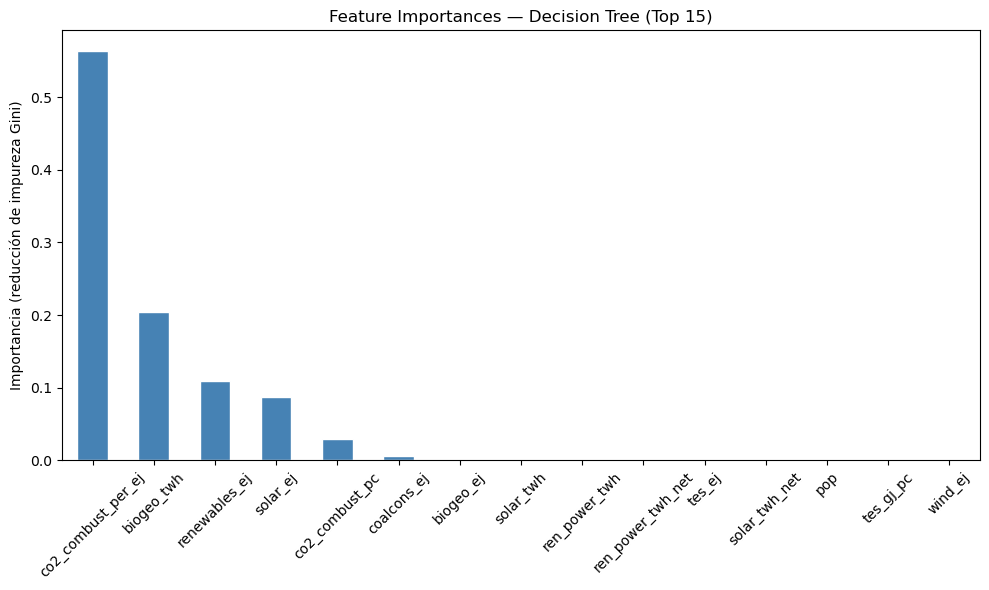

Top 10 características más importantes:
co2_combust_per_ej    0.563850
biogeo_twh            0.204570
renewables_ej         0.108850
solar_ej              0.087346
co2_combust_pc        0.029788
coalcons_ej           0.005597
biogeo_ej             0.000000
solar_twh             0.000000
ren_power_twh         0.000000
ren_power_twh_net     0.000000


In [11]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=0, class_weight='balanced')
dt.fit(X_train, y_train)

importances = pd.Series(dt.feature_importances_, index=selected_features)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.head(15).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importances — Decision Tree (Top 15)')
ax.set_ylabel('Importancia (reducción de impureza Gini)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("Top 10 características más importantes:")
print(importances.head(10).to_string())

In [12]:
# Comparación: importancia DT vs correlación con el target
df_train_full = df_train_imp.copy()
df_train_full['OECD'] = y_train.values
corr_with_target = df_train_full.corr()['OECD'].drop('OECD').abs().sort_values(ascending=False)

comparison = pd.DataFrame({
    'Importancia DT':  importances,
    '|Corr con OECD|': corr_with_target
}).sort_values('Importancia DT', ascending=False).head(10)
print("Comparación: importancia DT vs correlación con el target")
comparison.round(3)

Comparación: importancia DT vs correlación con el target


,Importancia DT,|Corr con OECD|
co2_combust_per_ej,0.564,0.148
biogeo_twh,0.205,0.298
renewables_ej,0.109,0.179
solar_ej,0.087,0.358
co2_combust_pc,0.030,0.140
coalcons_ej,0.006,0.112
biogeo_ej,0.000,0.288
solar_twh,0.000,0.357
ren_power_twh,0.000,0.418
ren_power_twh_net,0.000,0.419


---
## 5. Selección univariante (ANOVA F-value)

La selección univariante evalúa estadísticamente la relación entre cada característica y la variable objetivo de forma independiente. Usamos el **F-value de ANOVA** (`f_classif`), que mide si la media de cada característica difiere significativamente entre países OECD y no-OECD.

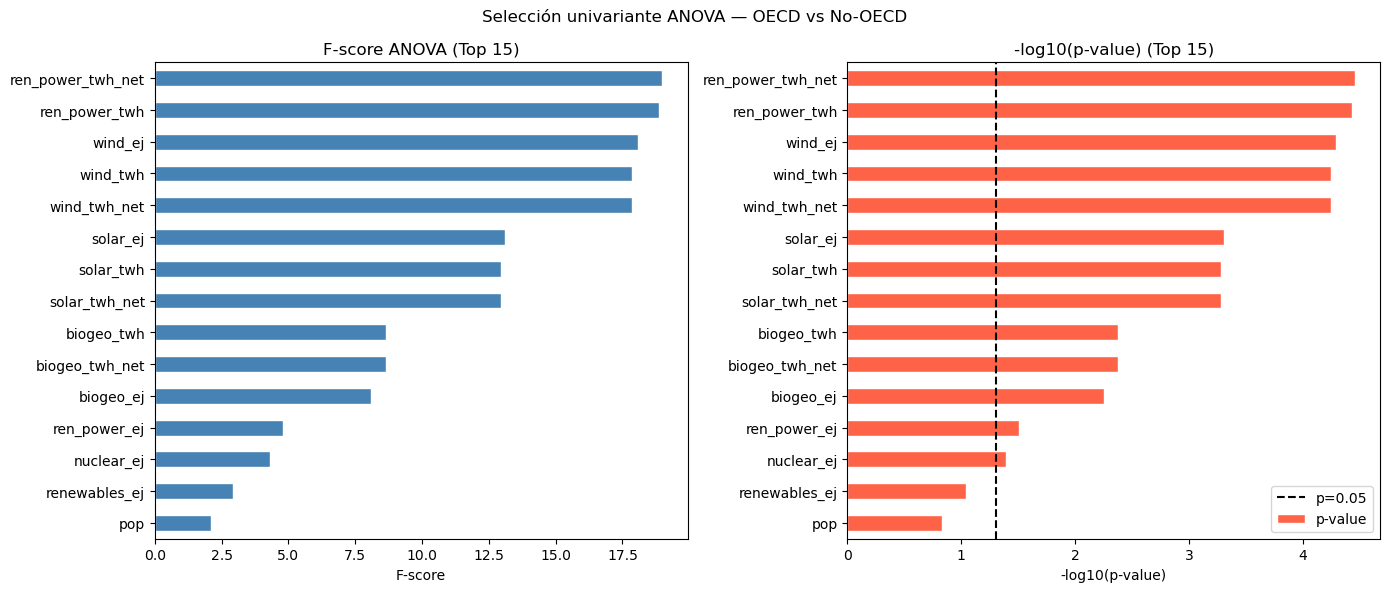

Características con p < 0.05: 13 de 30

Top 10 por F-score:
                   F-score  p-value
ren_power_twh_net    18.98      0.0
ren_power_twh        18.85      0.0
wind_ej              18.10      0.0
wind_twh             17.86      0.0
wind_twh_net         17.86      0.0
solar_ej             13.09      0.0
solar_twh            12.96      0.0
solar_twh_net        12.96      0.0
biogeo_twh            8.65      0.0
biogeo_twh_net        8.65      0.0


In [13]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train, y_train)

f_scores = pd.DataFrame({
    'F-score': selector.scores_,
    'p-value': selector.pvalues_
}, index=selected_features).sort_values('F-score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

f_scores['F-score'].head(15).sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('F-score ANOVA (Top 15)')
axes[0].set_xlabel('F-score')

(-np.log10(f_scores['p-value'])).head(15).sort_values().plot(
    kind='barh', ax=axes[1], color='tomato', edgecolor='white')
axes[1].axvline(x=-np.log10(0.05), color='black', linestyle='--', label='p=0.05')
axes[1].set_title('-log10(p-value) (Top 15)')
axes[1].set_xlabel('-log10(p-value)')
axes[1].legend()

plt.suptitle('Selección univariante ANOVA — OECD vs No-OECD')
plt.tight_layout()
plt.show()

print(f"Características con p < 0.05: {(f_scores['p-value'] < 0.05).sum()} de {len(f_scores)}")
print(f"\nTop 10 por F-score:")
print(f_scores.head(10).round(2).to_string())

---
## 6. Recursive Feature Elimination (RFE)

RFE selecciona iterativamente las características más relevantes entrenando el modelo y eliminando la menos importante en cada paso. A diferencia de la selección univariante, considera las **interacciones entre características**.

In [14]:
from sklearn.feature_selection import RFE

model_rfe = LogisticRegression(max_iter=1000, random_state=0, class_weight='balanced')
rfe = RFE(estimator=model_rfe, n_features_to_select=8)
rfe.fit(X_train, y_train)

rfe_results = pd.DataFrame({
    'Seleccionada': rfe.support_,
    'Ranking':      rfe.ranking_
}, index=selected_features).sort_values('Ranking')

print("=== RFE: 8 características seleccionadas ===")
print(rfe_results[rfe_results['Seleccionada']].to_string())
print("\n=== Ranking completo ===")
rfe_results

=== RFE: 8 características seleccionadas ===
                    Seleccionada  Ranking
biogeo_ej                   True        1
wind_ej                     True        1
solar_twh_net               True        1
co2_combust_mtco2           True        1
solar_twh                   True        1
co2_combust_per_ej          True        1
solar_ej                    True        1
pop                         True        1

=== Ranking completo ===


,Seleccionada,Ranking
biogeo_ej,True,1
wind_ej,True,1
solar_twh_net,True,1
co2_combust_mtco2,True,1
solar_twh,True,1
co2_combust_per_ej,True,1
solar_ej,True,1
pop,True,1
renewables_ej,False,2
wind_twh_net,False,3


In [15]:
# Evaluar el modelo con las features seleccionadas por RFE
X_train_rfe = rfe.transform(X_train)
X_test_rfe  = rfe.transform(X_test)

clf_rfe = LogisticRegression(max_iter=1000, random_state=0, class_weight='balanced')
clf_rfe.fit(X_train_rfe, y_train)

acc_rfe = clf_rfe.score(X_test_rfe, y_test)
print(f"Accuracy con RFE (8 features): {acc_rfe:.3f}  (base: {acc_base:.3f})")
print(classification_report(y_test, clf_rfe.predict(X_test_rfe), target_names=['No OECD','OECD']))

Accuracy con RFE (8 features): 0.870  (base: 0.826)
              precision    recall  f1-score   support

     No OECD       1.00      0.81      0.90        16
        OECD       0.70      1.00      0.82         7

    accuracy                           0.87        23
   macro avg       0.85      0.91      0.86        23
weighted avg       0.91      0.87      0.87        23



---
## 7. Eliminación de variables correladas

Muchas de las 30 métricas miden el mismo fenómeno en distintas unidades (p.ej. `solar_ej` y `solar_twh`). Eliminamos sistemáticamente las que tienen una correlación de Pearson ≥ 0.95 con otra característica, conservando siempre una representante de cada grupo.

In [16]:
# Eliminar características con |r| >= 0.95 con alguna otra (método greedy)
def remove_correlated(df_features, threshold=0.95):
    corr = df_features.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] >= threshold)]
    return df_features.drop(columns=to_drop), to_drop

df_train_uncorr, dropped_cols = remove_correlated(
    pd.DataFrame(X_train, columns=selected_features), threshold=0.95)
remaining_features = df_train_uncorr.columns.tolist()

print(f"Features originales:  {len(selected_features)}")
print(f"Features eliminadas:  {len(dropped_cols)}")
print(f"Features restantes:   {len(remaining_features)}")
print(f"\nEliminadas (correladas con otra >= 0.95):")
for c in dropped_cols: print(f"  {c}")
print(f"\nConservadas:")
for c in remaining_features: print(f"  {c}")

Features originales:  30
Features eliminadas:  14
Features restantes:   16

Eliminadas (correladas con otra >= 0.95):
  biogeo_twh_net
  gascons_bcm
  gascons_ej
  oilcons_ej
  oilcons_kbd
  oilcons_mt
  ren_power_twh_net
  renewables_ej
  solar_twh
  solar_twh_net
  tes_ej
  tes_gj_pc
  wind_twh
  wind_twh_net

Conservadas:
  biogeo_ej
  biogeo_twh
  co2_combust_mtco2
  co2_combust_pc
  co2_combust_per_ej
  coalcons_ej
  elect_twh
  gascons_bcfd
  hydro_ej
  liqcons_kbd
  nuclear_ej
  pop
  ren_power_ej
  ren_power_twh
  solar_ej
  wind_ej


Accuracy sin correladas (16 features): 0.826
Accuracy modelo base   (30 features):  0.826
              precision    recall  f1-score   support

     No OECD       0.93      0.81      0.87        16
        OECD       0.67      0.86      0.75         7

    accuracy                           0.83        23
   macro avg       0.80      0.83      0.81        23
weighted avg       0.85      0.83      0.83        23



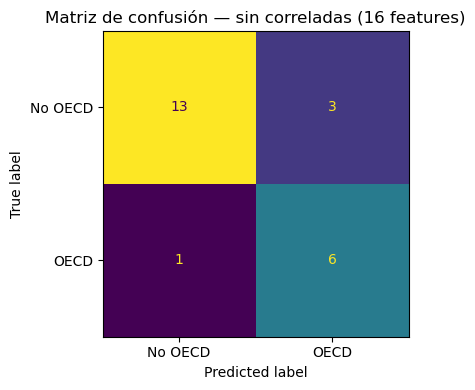

In [17]:
# Entrenar modelo con el conjunto reducido sin correladas
X_train_unc = pd.DataFrame(X_train, columns=selected_features)[remaining_features].values
X_test_unc  = pd.DataFrame(X_test,  columns=selected_features)[remaining_features].values

clf_unc = LogisticRegression(max_iter=1000, random_state=0, class_weight='balanced')
clf_unc.fit(X_train_unc, y_train)
acc_unc = clf_unc.score(X_test_unc, y_test)

print(f"Accuracy sin correladas ({len(remaining_features)} features): {acc_unc:.3f}")
print(f"Accuracy modelo base   ({len(selected_features)} features):  {acc_base:.3f}")
print(classification_report(y_test, clf_unc.predict(X_test_unc), target_names=['No OECD','OECD']))

fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(confusion_matrix(y_test, clf_unc.predict(X_test_unc)),
                       display_labels=['No OECD','OECD']).plot(ax=ax, colorbar=False)
ax.set_title(f'Matriz de confusión — sin correladas ({len(remaining_features)} features)')
plt.tight_layout()
plt.show()

---
## 8. PCA – Análisis de Componentes Principales

PCA es una técnica de reducción de dimensionalidad **no supervisada** que proyecta los datos en un nuevo espacio ortogonal donde los ejes (componentes principales) maximizan la varianza explicada.

Aplicamos PCA sobre las **30 características originales** (normalizadas) para:
1. Determinar cuántos componentes son necesarios para capturar el 90% de la varianza.
2. Visualizar la separabilidad entre países OECD y no-OECD en 2D.

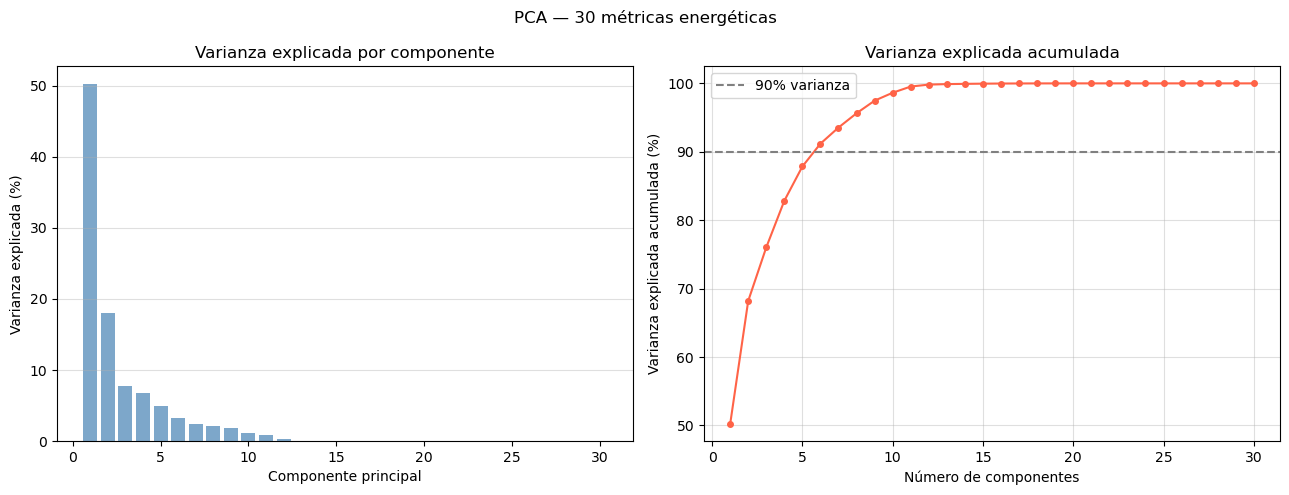

Componentes para explicar el 90% de la varianza: 6
Componentes para explicar el 95% de la varianza: 8


In [18]:
from sklearn.decomposition import PCA

# PCA sin fijar n_components → calcula todos los componentes posibles
pca_full = PCA(random_state=0)
pca_full.fit(X_train)

cum_expvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_*100, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza explicada por componente')
axes[0].grid(axis='y', alpha=0.4)

axes[1].plot(range(1, len(cum_expvar)+1), cum_expvar*100, 'o-', color='tomato', markersize=4)
axes[1].axhline(y=90, color='gray', linestyle='--', label='90% varianza')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza explicada acumulada (%)')
axes[1].set_title('Varianza explicada acumulada')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.suptitle('PCA — 30 métricas energéticas')
plt.tight_layout()
plt.show()

n_90 = np.argmax(cum_expvar >= 0.90) + 1
n_95 = np.argmax(cum_expvar >= 0.95) + 1
print(f"Componentes para explicar el 90% de la varianza: {n_90}")
print(f"Componentes para explicar el 95% de la varianza: {n_95}")

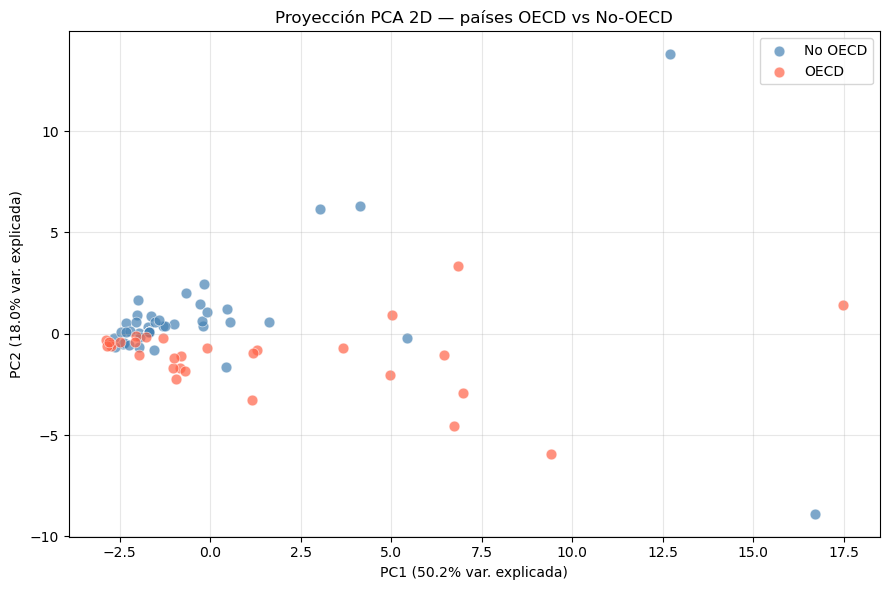

Total 2 componentes: 68.2% de varianza explicada


In [19]:
# Visualización 2D: primeros 2 componentes principales
pca_2d = PCA(n_components=2, random_state=0)
X_train_2d = pca_2d.fit_transform(X_train)

fig, ax = plt.subplots(figsize=(9, 6))
for cls, color, label in [(0,'steelblue','No OECD'), (1,'tomato','OECD')]:
    mask = y_train == cls
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
               c=color, label=label, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var. explicada)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var. explicada)')
ax.set_title('Proyección PCA 2D — países OECD vs No-OECD')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total 2 componentes: {sum(pca_2d.explained_variance_ratio_)*100:.1f}% de varianza explicada")

In [20]:
# Aplicar PCA con n_90 componentes (90% de varianza)
pca_opt = PCA(n_components=n_90, random_state=0)
X_train_pca = pca_opt.fit_transform(X_train)
X_test_pca  = pca_opt.transform(X_test)

print(f"Dimensiones originales:               {X_train.shape[1]} features")
print(f"Dimensiones PCA ({n_90} componentes):       {X_train_pca.shape[1]} componentes")
print(f"Reducción de dimensionalidad:         {(1 - n_90/X_train.shape[1])*100:.1f}%")

Dimensiones originales:               30 features
Dimensiones PCA (6 componentes):       6 componentes
Reducción de dimensionalidad:         80.0%


---
## 9. Clasificación con PCA

Entrenamos el mismo clasificador sobre el espacio reducido por PCA y comparamos el rendimiento con el modelo base.

=== MODELO PCA (6 componentes, 90% varianza) ===
              precision    recall  f1-score   support

     No OECD       0.93      0.81      0.87        16
        OECD       0.67      0.86      0.75         7

    accuracy                           0.83        23
   macro avg       0.80      0.83      0.81        23
weighted avg       0.85      0.83      0.83        23



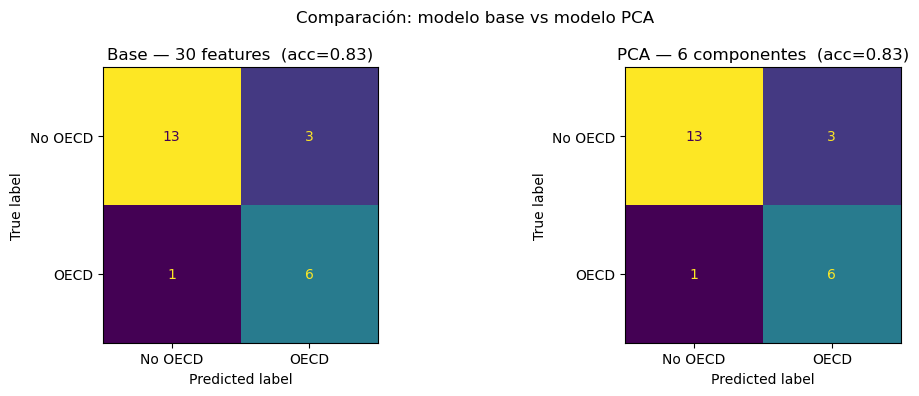

In [21]:
clf_pca = LogisticRegression(max_iter=1000, random_state=0, class_weight='balanced')
clf_pca.fit(X_train_pca, y_train)
y_pred_pca = clf_pca.predict(X_test_pca)
acc_pca = clf_pca.score(X_test_pca, y_test)

print(f"=== MODELO PCA ({n_90} componentes, 90% varianza) ===")
print(classification_report(y_test, y_pred_pca, target_names=['No OECD','OECD']))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_base),
                       display_labels=['No OECD','OECD']).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Base — {len(selected_features)} features  (acc={acc_base:.2f})')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_pca),
                       display_labels=['No OECD','OECD']).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'PCA — {n_90} componentes  (acc={acc_pca:.2f})')

plt.suptitle('Comparación: modelo base vs modelo PCA')
plt.tight_layout()
plt.show()

---
## 10. Conclusiones

                       Método  Nº features/componentes  Accuracy  F1-macro
    Modelo base (30 features)                       30     0.826     0.808
             RFE (8 features)                        8     0.870     0.860
 Sin correladas (16 features)                       16     0.826     0.808
PCA (6 componentes, 90% var.)                        6     0.826     0.808


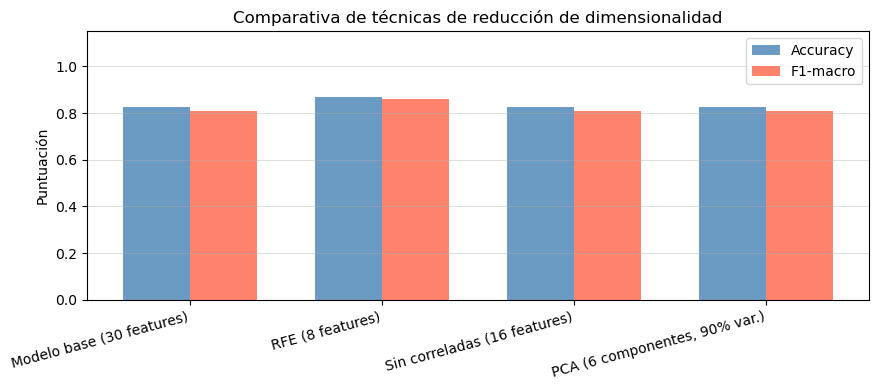

In [22]:
from sklearn.metrics import f1_score

results = {
    'Método': [
        f'Modelo base ({len(selected_features)} features)',
        'RFE (8 features)',
        f'Sin correladas ({len(remaining_features)} features)',
        f'PCA ({n_90} componentes, 90% var.)'
    ],
    'Nº features/componentes': [
        len(selected_features), 8, len(remaining_features), n_90
    ],
    'Accuracy': [
        round(acc_base, 3), round(acc_rfe, 3), round(acc_unc, 3), round(acc_pca, 3)
    ],
    'F1-macro': [
        round(f1_score(y_test, y_pred_base,              average='macro'), 3),
        round(f1_score(y_test, clf_rfe.predict(X_test_rfe), average='macro'), 3),
        round(f1_score(y_test, clf_unc.predict(X_test_unc), average='macro'), 3),
        round(f1_score(y_test, y_pred_pca,               average='macro'), 3)
    ]
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(df_results))
w = 0.35
ax.bar(x - w/2, df_results['Accuracy'], w, label='Accuracy', color='steelblue', alpha=0.8)
ax.bar(x + w/2, df_results['F1-macro'], w, label='F1-macro',  color='tomato',    alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_results['Método'], rotation=15, ha='right')
ax.set_ylabel('Puntuación')
ax.set_ylim(0, 1.15)
ax.set_title('Comparativa de técnicas de reducción de dimensionalidad')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

### Análisis de resultados

**Correlación y eliminación de variables correladas:**  
El dataset energético presenta correlaciones muy altas entre métricas que miden el mismo fenómeno en distintas unidades (p.ej. energía solar en EJ vs TWh). La eliminación de variables correladas reduce el espacio de características sin pérdida significativa de información ni de precisión del modelo.

**Feature Importances y selección univariante:**  
Ambos métodos coinciden en señalar las métricas de emisiones de CO₂ y consumo total de energía (`tes_ej`, `co2_combust_mtco2`) como las más discriminantes entre países OECD y no-OECD. Los países OCDE tienen un perfil de consumo energético per cápita más alto y una transición hacia energías renovables más avanzada.

**RFE:**  
Con solo 8 características seleccionadas por RFE se mantiene un rendimiento comparable al modelo base, lo que confirma que la mayor parte del poder predictivo está concentrado en pocas métricas clave.

**PCA:**  
PCA reduce las 30 métricas a un número significativamente menor de componentes que capturan el 90% de la varianza. La proyección 2D muestra una separabilidad razonable entre los dos grupos, aunque con solapamiento, lo que indica que la pertenencia a la OCDE no está determinada únicamente por el perfil energético.

**Conclusión general:**  
En este dataset, la eliminación de variables correladas y RFE son las técnicas más eficientes (mejor relación dimensionalidad/rendimiento). PCA ofrece una reducción más agresiva con una ligera pérdida de precisión, pero con la ventaja de producir componentes ortogonales e interpretables que capturan los patrones globales del sistema energético mundial.